# Polymer Scaling and Protein Domain Size
This notebook demonstrates how to fit the protein domain size parameter ($a$) for polymer cosolutes, specifically Polyethylene Glycols (PEGs) of various molecular weights. 

## Theoretical Background
As shown by *Stewart et al. (2023)* and *Olgenblum & Harries (2026)*, polymer crowders behave fundamentally differently from rigid hard-sphere depletiants:
1. **Dilute Regime**: Depletion is governed by the individual polymer coil's radius of gyration ($R_g$), and interactions scale linearly with concentration.
2. **Semidilute Regime**: Above the overlap concentration ($c^*$), the polymer coils interpenetrate to form a transient mesh. The relevant length scale becomes the correlation length ($\xi$). 

In our `CrowdingModel`, the protein domain size $a$ characterizes the range of the depletion interaction. Therefore, when crowding with polymers in the semidilute regime, $a$ should scale with the mesh size $\xi$, rather than remaining constant or scaling with individual polymer size.

We will extract experimental unfolding free energy ($\Delta\Delta G^0_U^\circ$) data for the N-terminal SH3 domain of *Drosophila* drk in presence of various PEGs (data from *Stewart et al. (2023)*) and use `fit_a()` to find the corresponding domain sizes.


In [1]:
import crowding as cr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Suppress minor warnings for clean output
warnings.filterwarnings('ignore')
np.seterr(all='ignore')

# Set up matplotlib style
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14


## 1. Load Experimental Data
We will load the thermodynamic data from `WT SH3 Stability in PEGs.xlsx`. The data is spread across different sheets for 100 g/L, 200 g/L, and 300 g/L concentrations (for some PEGs also at 25 and 50g/L).
We will convert $\Delta\Delta G^0$=$-4.184\;\Delta\Delta G^0_U$ to  (unfolding in kcal/mol to folding in kJ/mol).

In [2]:
from pathlib import Path

# Locate the sample data path robustly
ROOT = Path.cwd()
while not (ROOT / "app").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

file_path = ROOT / 'app' / 'sample_data' / 'sh3_peg_stability.csv'

# Read CSV
df = pd.read_csv(file_path)

data_dict = {}

for _, row in df.iterrows():
    cosolute = str(row['Cosolute']).strip()
    conc = float(row['Concentration_gL'])
    ddG = float(row['ddG'])
    
    if cosolute not in data_dict:
        data_dict[cosolute] = {'conc': [], 'ddG': []}
        
    data_dict[cosolute]['conc'].append(conc) # g/L
    data_dict[cosolute]['ddG'].append(ddG*-4.184) # kcal/mol to kJ/mol and unfolding to folding free energy

print(f"Loaded data for {len(data_dict)} cosolutes.")

Loaded data for 5 cosolutes.


## 2. Model Configuration
We will define the `Protein` (SH3) and loop over the cosolutes to fit the parameter $a$. 
To isolate the excluded volume and mixing effects, we assume the soft interaction parameter ($\varepsilon$) is 0 for large PEGs. We need to assign appropriate $\nu$ and $\chi$ values for each PEG, whic we take from *Stewart et al. (2023)*.

The resulting values of the protain domain size will be plotted *versus* PEG molar concetration scaled to the overlap concentration $c^*$, which is the concentration in which PEGs start to overlap. The overlap concentration is given by:
$$
c^*=\left[N_{av}\left(\frac{4}{3}\pi R_g^3\right)\right]^{-1}
$$
For PEGs in water (good solvent):
$$
c^*\sim 3.98\cdot 10^4 \; Mw^{-1.749}
$$


In [3]:
#helper funciton
def c_star(Mw):
    return 3.98*1E4*Mw**-1.749 # for

In [4]:
# Initialize Protein
protein = cr.Protein(SASA=2_200.0) # SH3 domain

# properties for PEGs.
peg_properties = {
    '400 PEG': {'nu': 18.7, 'chi': 0.38, 'mw': 400},
    '1000 PEG': {'nu': 47.3, 'chi': 0.38, 'mw': 1000},
    '3350 PEG': {'nu': 156, 'chi': 0.4, 'mw': 3350},
    '8000 PEG': {'nu': 371, 'chi': 0.4, 'mw': 8000},
    '20000 PEG': {'nu': 910, 'chi': 0.4, 'mw': 20000},
}

## loop over all PEGs and fit to data
results = []

for name, props in peg_properties.items():
    if name in data_dict:
        print(name)
        # Experimental data
        concs_gL = np.array(data_dict[name]['conc'])
        ddGs = np.array(data_dict[name]['ddG'])
        
        # Initialize model
        cosolute = cr.Cosolute(nu=props['nu'], chi=props['chi'], chiTS=0)
        model = cr.CrowdingModel(protein=protein, cosolute=cosolute)
        
        # Convert g/L to Molar
        molar_exp = concs_gL / peg_properties[name]['mw']

        try:
            model.fit_a(exp_ddG=ddGs, exp_conc=molar_exp, concentration_type='molar', progress_bar=True, disp=False) # we specify the concentration type!
            
            #save the results 
            results.append({
                'Name': name,
                'MW': props['mw'],
                'c': molar_exp,
                'c_star': c_star(props['mw']),
                'c/c_star': molar_exp/c_star(props['mw']),
                'a': model.fitted_a
            })
            #print(f"Fitted {name:15s} | MW: {props['mw']:5d} | a: {fitted_a:.2f}")
        except Exception as e:
            print(f"Failed to fit {name}: {e}")

400 PEG


Fitting a: 0iter [00:00, ?iter/s]

1000 PEG


Fitting a: 0iter [00:00, ?iter/s]

3350 PEG


Fitting a: 0iter [00:00, ?iter/s]

8000 PEG


Fitting a: 0iter [00:00, ?iter/s]

20000 PEG


Fitting a: 0iter [00:00, ?iter/s]

## 3. Visualize Polymer Scaling
In polymer physics, the mesh size, $\xi$, of a polymer in a godd solvent (like PEG in water) scales as $c^{-0.77}$ in the semi dilute regime (i.e., for $c/c^*>1$). The protein domain size $a$ scales as tge mesh size.
We plot $\log(a)$ vs $\log(Mw)$ to observe this scaling behavior.


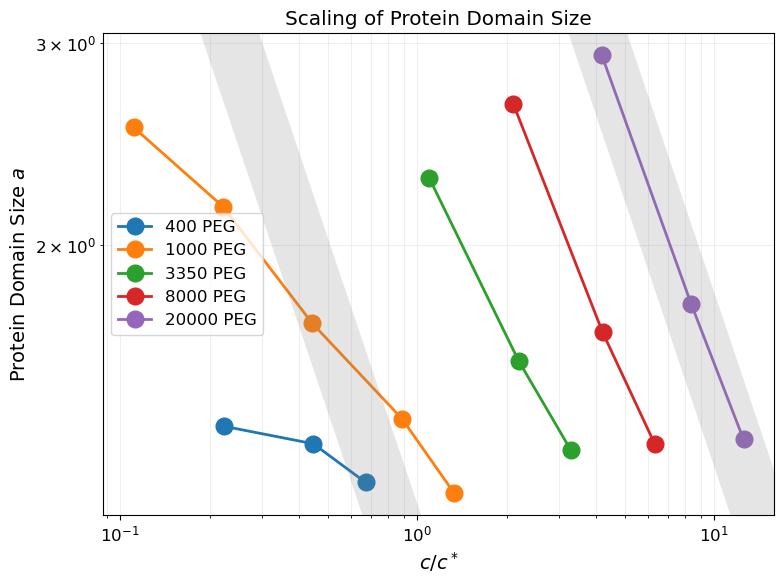

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))

# Log-Log plot
for PEG in results:
    ax.loglog(PEG['c/c_star'], PEG['a'],'o-', markersize=12, linewidth=2, label=PEG['Name'])

xlim = ax.get_xlim()
ylim = ax.get_ylim()

c_ref = np.arange(0.001,PEG['c/c_star'].max()*10)
c_ideal = c_ref**-0.77 # theoretical
ax.loglog(c_ref, c_ideal,'-', c='gray', linewidth=40, alpha=0.2, label='')  # theoretical curve
ax.loglog(c_ref, c_ideal*9,'-', c='gray', linewidth=40, alpha=0.2, label='')  # theoretical curve shifted to the right

ax.set_xlabel(r'$c/c^*$')
ax.set_ylabel(r'Protein Domain Size $a$')
ax.set_title('Scaling of Protein Domain Size')
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.2)

ax.set_xlim(xlim)
ax.set_ylim(ylim)


plt.tight_layout()
plt.show()
